In [1]:
from pathlib import Path

import lasio 
import geopandas as gpd

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.gaussian_process import GaussianProcessClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.mixture import BayesianGaussianMixture

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

In [2]:
# Input and output paths
ROOT = Path().resolve().parent
RAW  = ROOT / 'data' / 'raw'
PROCESSED = ROOT / 'data' / 'processed' 
OUTPUT = ROOT / 'output'
OUTPUT.mkdir(parents=True, exist_ok=True)

In [3]:
# Clean dataset
raw_data = pd.read_csv(PROCESSED / "target_lithologies_filled.csv")
raw_data.info()

# Utrecht boundaries
utrecht_city = gpd.read_file(PROCESSED / 'utrecht_city.gpkg')
utrecht_province = gpd.read_file(PROCESSED / 'utrecht_province.gpkg')

<class 'pandas.DataFrame'>
RangeIndex: 4035 entries, 0 to 4034
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   well_id                4035 non-null   str    
 1   easting                4035 non-null   float64
 2   northing               4035 non-null   float64
 3   depth_tvd_m            4035 non-null   float64
 4   porosity_pct           4035 non-null   float64
 5   gamma_ray_api          4035 non-null   float64
 6   bulk_density_gcc       4035 non-null   float64
 7   formation_thickness_m  4035 non-null   float64
 8   formation_top_tvd      4035 non-null   float64
 9   formation_base_tvd     4035 non-null   float64
 10  distance_to_usp_km     4035 non-null   float64
dtypes: float64(10), str(1)
memory usage: 346.9 KB


In [4]:
df = raw_data.copy()
well_list = df["well_id"].unique().tolist()

### Temperature

In [5]:
dfs_las = {}

for well in well_list:
    las = lasio.read(RAW / f"{well}.las")
    
    df_las = las.df().reset_index()
    dfs_las[well] = df_las

    print(f"\n=========================================")
    print(f"Well Name: {well}")
    print(f"DataFrame Shape: {df_las.shape}")
    print(f"=========================================")
    
    print("--- HEADER METADATA ---")
    for item in las.well:
        print(f"{item.mnemonic:<10} | {item.descr:<40} : {item.value}")



Well Name: EVD-01
DataFrame Shape: (21569, 5)
--- HEADER METADATA ---
STRT       | First Index Value                        : 2196.9004
STOP       | Last Index Value                         : 40.1002
STEP       | Frame Spacing                            : -0.1
NULL       | Absent Value                             : -999.25
WELL       | Well Name                                : EVERDINGEN-01
FLD        | Field Name                               : UNKNOWN
CNTY       | County                                   : 
STAT       | State                                    : 
CTRY       | Country                                  : 
LOC        | Location                                 : 
API        | API Number                               : 
DATE       | Date                                     : 
COMP       | Company Name                             : NAM
SRVC       | Service Company                          : 

Well Name: PKP-01
DataFrame Shape: (27508, 6)
--- HEADER METADATA ---
STRT      

$$\text{Geothermal Gradient Model for Temperature}$$

$$ T(z) = T_s + G \cdot z $$

In [6]:
# Netherlands mean annual surface temperature
surface_temp_c = 10.0

# From BLT-01 Header Information
blt_bht = 167
blt_strt = 0
blt_tdl = 2123.8

# Fahrenheit to Celcius
blt_bht_c = (blt_bht - 32) / 1.8

gradient = (blt_bht_c - surface_temp_c) / (blt_tdl - blt_strt) 

df["temp_est_c"] = surface_temp_c + gradient * df["depth_tvd_m"]

gradients = {"BLT-01": gradient}
default_gradient = gradient

df["gradient_used"] = df["well_id"].map(gradients).fillna(default_gradient)
df["temp_est_c"] = surface_temp_c + df["gradient_used"] * df["depth_tvd_m"]

## Reservoir Quality

$$ RQI = w_{1}\phi + w_{2}h + w_{3}T - w_{4}GR - w_{5}D$$

### RQI Baseline 

In [7]:
# Aggregate of well into one spatial location
well_agg = df.groupby("well_id").agg(
    phi=("porosity_pct", "mean"),           
    h=("formation_thickness_m", "first"),
    t=("temp_est_c", "mean"),  
    gr=("gamma_ray_api", "mean"),
    d=("depth_tvd_m", "mean"),
    easting=("easting", "first"),
    northing=("northing", "first"),
).reset_index()

features = ["phi", "h", "t", "gr", "d"]
norm_cols = ["phi_norm", "h_norm", "t_norm", "gr_norm", "d_norm"]

scaler = MinMaxScaler()
well_agg[norm_cols] = scaler.fit_transform(well_agg[features])

# Baseline where all features have equal weights
w1, w2, w3, w4, w5 = 0.20, 0.20, 0.20, 0.20, 0.20

well_agg["quality_score"] = (
    w1 * well_agg["phi_norm"]
    + w2 * well_agg["h_norm"]
    + w3 * well_agg["t_norm"]
    - w4 * well_agg["gr_norm"]
    - w5 * well_agg["d_norm"]
)

## Unsupervised Clustering

In [8]:
feature_cols = ["depth_tvd_m", "porosity_pct", "gamma_ray_api", "bulk_density_gcc", "temp_est_c", "formation_thickness_m"]
X = df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

well_features = df.groupby("well_id")[feature_cols].mean()
n_wells = len(well_features)

well_scaler = StandardScaler()
well_X_scaled = well_scaler.fit_transform(well_features)

print(f"Clustering will be performed on {n_wells} wells: {list(well_features.index)}")

Clustering will be performed on 4 wells: ['BLT-01', 'EVD-01', 'JUT-01', 'PKP-01']


### K- Means Clustering

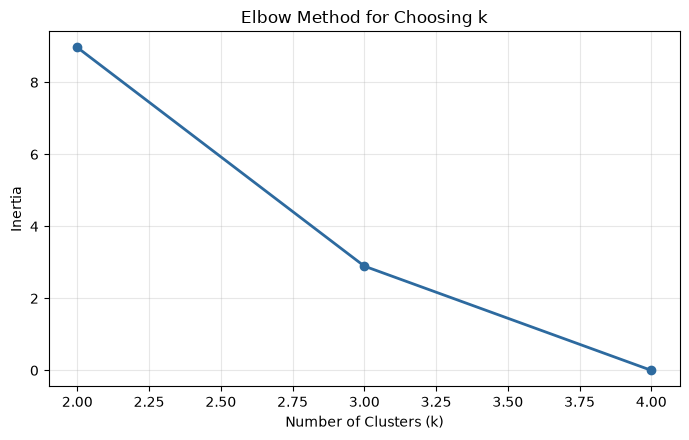

k=2: inertia=9.0
k=3: inertia=2.9
k=4: inertia=0.0


In [9]:
k_range = range(2, n_wells + 1)

inertias = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(well_X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(list(k_range), inertias, marker="o", color="#2d6a9f", linewidth=2)
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia")
ax.set_title("Elbow Method for Choosing k")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for k, inertia in zip(k_range, inertias):
    print(f"k={k}: inertia={inertia:.1f}")

In [10]:
k = min(4, max(1, n_wells - 1))
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
well_cluster_labels = kmeans.fit_predict(well_X_scaled)

well_features["Cluster"] = well_cluster_labels
df["Cluster"] = df["well_id"].map(well_features["Cluster"])

print(f"Trained K-Means with k={k} on {n_wells} wells (clustering per well)")

Trained K-Means with k=3 on 4 wells (clustering per well)


### Principal Component Analysis (PCA) Clustering

In [11]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]

print("Explained variance ratio per component:")
for i, var in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"  PC{i}: {var:.3f} ({var*100:.1f}% of variance)")
print(f"\nTotal variance captured by PC1 + PC2: {pca.explained_variance_ratio_.sum()*100:.1f}%")

Explained variance ratio per component:
  PC1: 0.588 (58.8% of variance)
  PC2: 0.314 (31.4% of variance)

Total variance captured by PC1 + PC2: 90.2%


In [12]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=feature_cols
).round(3)

loadings

,PC1,PC2
depth_tvd_m,0.480,0.297
porosity_pct,-0.296,0.594
gamma_ray_api,0.389,0.416
bulk_density_gcc,0.345,-0.491
temp_est_c,0.480,0.297
formation_thickness_m,-0.427,0.238


In [13]:
favorable_corr = np.corrcoef(X_pca[:, 0], df["porosity_pct"])[0, 1]
pc1_sign = -1 if favorable_corr < 0 else 1

df["PC1_quality"] = pc1_sign * df["PC1"]
print(f"Correlation of raw PC1 with porosity: {favorable_corr:.3f}")
print(f"PC1 sign flipped for quality scoring: {pc1_sign == -1}")

Correlation of raw PC1 with porosity: -0.555
PC1 sign flipped for quality scoring: True


In [14]:
well_pca_quality = (
    df.groupby("well_id")["PC1_quality"]
    .mean()
    .rename("pca_quality_score")
    .reset_index()
)

### Gaussian Mixture Clustering (GMM)

In [15]:
n_components = min(8, max(2, n_wells - 1))
bgm = BayesianGaussianMixture(
    n_components=n_components,
    covariance_type="full",
    weight_concentration_prior_type="dirichlet_process",
    random_state=42,
    max_iter=500,
)
well_gmm_labels = bgm.fit_predict(well_X_scaled)
well_features["GMM_Cluster"] = well_gmm_labels
df["GMM_Cluster"] = df["well_id"].map(well_features["GMM_Cluster"])

effective_components = int(np.sum(bgm.weights_ > 0.01))
print(f"Bayesian Gaussian Mixture clustered {n_wells} wells (per well, not per row)")
print(f"Components with non-trivial weight: {effective_components} (of {bgm.n_components} allowed)")
print("\nWell -> GMM cluster assignment:")
print(well_features["GMM_Cluster"])
print("\nRows per GMM cluster (inherited from each row's well):")
print(df["GMM_Cluster"].value_counts().sort_index())

Bayesian Gaussian Mixture clustered 4 wells (per well, not per row)
Components with non-trivial weight: 3 (of 3 allowed)

Well -> GMM cluster assignment:
well_id
BLT-01    2
EVD-01    0
JUT-01    0
PKP-01    1
Name: GMM_Cluster, dtype: int64

Rows per GMM cluster (inherited from each row's well):
GMM_Cluster
0    1616
1     730
2    1689
Name: count, dtype: int64


In [16]:
def rank_and_classify(scores):
    ranks = scores.rank(method="min", ascending=False).astype(int)
    q1, q2, q3 = scores.quantile([0.25, 0.5, 0.75])
    def classify(s):
        if s <= q1: return "poor"
        elif s <= q2: return "marginal"
        elif s <= q3: return "good"
        else: return "excellent"
    return ranks, scores.apply(classify)

In [17]:
well_quality_lookup = well_agg.set_index("well_id")["quality_score"]
well_features["rqi_quality_score"] = well_quality_lookup.reindex(well_features.index)
well_features["kmeans_quality_score"] = well_features.groupby("Cluster")["rqi_quality_score"].transform("mean")
well_features["pca_quality_score"] = well_pca_quality.set_index("well_id")["pca_quality_score"].reindex(well_features.index)
well_features["gmm_quality_score"] = well_features.groupby("GMM_Cluster")["rqi_quality_score"].transform("mean")

In [18]:
well_features["rqi_quality_rank"], well_features["rqi_quality_class"] = rank_and_classify(well_features["rqi_quality_score"])
well_features["kmeans_quality_rank"], well_features["kmeans_quality_class"] = rank_and_classify(well_features["kmeans_quality_score"])
well_features["pca_quality_rank"], well_features["pca_quality_class"] = rank_and_classify(well_features["pca_quality_score"])
well_features["gmm_quality_rank"], well_features["gmm_quality_class"] = rank_and_classify(well_features["gmm_quality_score"])

In [19]:
quality_comparison = well_features[["rqi_quality_class", "kmeans_quality_class", "pca_quality_class", "gmm_quality_class"]]
quality_comparison

,rqi_quality_class,kmeans_quality_class,pca_quality_class,gmm_quality_class
well_id,,,,
BLT-01,good,excellent,good,excellent
EVD-01,marginal,marginal,marginal,marginal
JUT-01,excellent,marginal,excellent,marginal
PKP-01,poor,poor,poor,poor


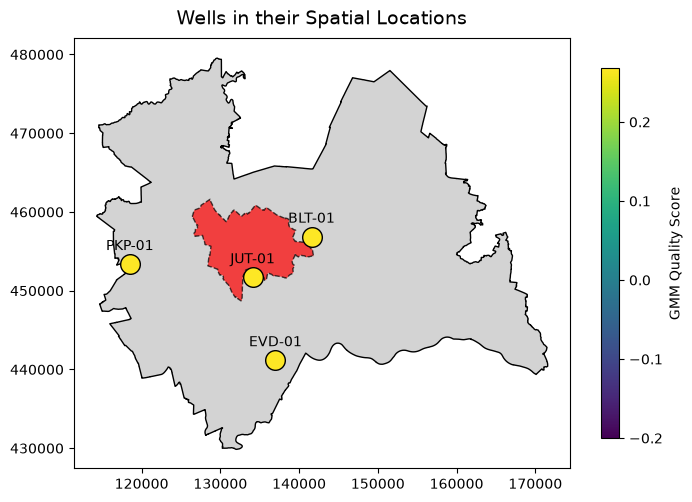

In [20]:
fig, ax = plt.subplots(figsize=(8, 8))

utrecht_province.plot(ax=ax, color="lightgrey", edgecolor='black')
utrecht_city.plot(ax=ax, color="red", edgecolor="black", linestyle="--", alpha=0.7)

for well in well_list:
    well_data = well_agg[well_agg["well_id"] == well]
    
    if not well_data.empty:
        x = well_data['easting'].values[0]
        y = well_data['northing'].values[0]
        score = well_features['gmm_quality_score'].values[0]
        
        sc = ax.scatter(x, y, c=[score], cmap='viridis', vmin=well_features['gmm_quality_score'].min(), vmax=well_features['gmm_quality_score'].max(), s=200, edgecolors='black', zorder=3)
        ax.annotate(well, (x, y), textcoords="offset points", xytext=(0,10), ha='center')

cbar = plt.colorbar(sc, ax=ax, shrink=0.6)
cbar.set_label('GMM Quality Score')

ax.set_title("Wells in their Spatial Locations", fontsize=14, pad=10)
plt.show()


## Supervised Machine Learning

### Random Forest Classification

### Gradient Boosted Classification

### Gaussian Process Classification